In [17]:
%matplotlib inline
import matplotlib.pyplot as plt
from matplotlib import rc
rc('font',size=18)

In [2]:
from pynitride.devices import gan_pfet
from pynitride.paramdb import nm,cm, k
from pynitride.solvers import PoissonSolver, Equilibrium, SelfConsistentLoop
from pynitride.carriers import Semiclassical, Schrodinger, MultibandKP

# Semiclassical

In [8]:
m,[scm,clm]=gan_pfet(10*nm,200*nm,Ndef=5e16/cm**3)

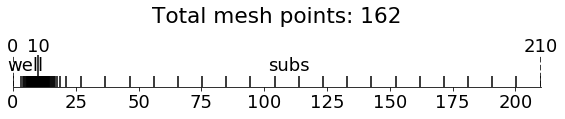

In [19]:
m.plot_mesh()

In [10]:
Equilibrium(m)
scl=SelfConsistentLoop(fieldsolvers=[PoissonSolver(m)],carriersolvers=[Semiclassical(m)])

Using explicit masses from file


In [11]:
scl.ramp_epsfactor(max_iter=20)

Starting eps factor ramp from 10000 to 1
  Eps factor: 1.00e+04
  Starting SC loop
    iter:   0  err: 9.24e-16  activ: 1
    Loop finished in  1 iterations with err=9.2382e-16
  Eps factor: 6.31e+03
  Starting SC loop
    iter:   0  err: 5.05e-04  activ: 1
    iter:   1  err: 6.02e-16  activ: 1
    Loop finished in  2 iterations with err=6.01693e-16
  Eps factor: 2.51e+03
  Starting SC loop
    iter:   0  err: 2.07e-03  activ: 1
    iter:   1  err: 3.03e-16  activ: 1
    Loop finished in  2 iterations with err=3.02562e-16
  Eps factor: 7.94e+02
  Starting SC loop
    iter:   0  err: 7.43e-03  activ: 1
    iter:   1  err: 3.00e-15  activ: 1
    Loop finished in  2 iterations with err=3.00011e-15
  Eps factor: 2.51e+02
  Starting SC loop
    iter:   0  err: 2.35e-02  activ: 1
    iter:   1  err: 2.97e-15  activ: 1
    Loop finished in  2 iterations with err=2.97073e-15
  Eps factor: 7.94e+01
  Starting SC loop
    iter:   0  err: 7.43e-02  activ: 1
    iter:   1  err: 3.58e-15  activ: 1

(0, 20)

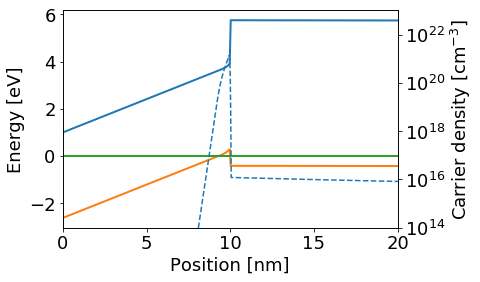

In [18]:
plt.figure()
plt.plot(m.zp,m.Ec,linewidth=2)
plt.plot(m.zp,m.Ev,linewidth=2)
plt.plot(m.zp,m.EF,linewidth=2)
plt.xlabel("Position [nm]")
plt.ylabel("Energy [eV]")

plt.twinx()
plt.plot(m.zp,m.p/(1/cm**3),'--')
plt.plot(m.zp,m.n/(1/cm**3),'--')
plt.yscale('log')
plt.ylabel("Carrier density [cm$^{-3}$]")
plt.ylim(1e14,1e23)

plt.xlim(0,20)

In [8]:
m.p.integrate(definite=True)/(1/cm**2)  /1e13

Function(3.4105609653666944)

# Schrodinger

In [21]:
m,[scm,clm]=gan_pfet(10*nm,200*nm,Ndef=5e16/cm**3,)

In [22]:
Equilibrium(m)

In [23]:
scl=SelfConsistentLoop(fieldsolvers=[PoissonSolver(m)],carriersolvers=[Schrodinger(scm),Semiclassical(clm)])

Using explicit masses from file
WHAT IS THIS BC
Using explicit masses from file


In [24]:
scl.ramp_epsfactor(max_iter=20)

Starting eps factor ramp from 10000 to 1
  Eps factor: 1.00e+04
  Starting SC loop
    iter:   0  err: 9.24e-16  activ: 1
    Loop finished in  1 iterations with err=9.23819e-16
  Eps factor: 6.31e+03
  Starting SC loop
    iter:   0  err: 5.05e-04  activ: 1
    iter:   1  err: 6.02e-16  activ: 1
    Loop finished in  2 iterations with err=6.017e-16
  Eps factor: 2.51e+03
  Starting SC loop
    iter:   0  err: 2.07e-03  activ: 1
    iter:   1  err: 3.03e-16  activ: 1
    Loop finished in  2 iterations with err=3.02556e-16
  Eps factor: 7.94e+02
  Starting SC loop
    iter:   0  err: 7.43e-03  activ: 1
    iter:   1  err: 3.00e-15  activ: 1
    Loop finished in  2 iterations with err=2.99859e-15
  Eps factor: 2.51e+02
  Starting SC loop
    iter:   0  err: 2.35e-02  activ: 1
    iter:   1  err: 2.97e-15  activ: 1
    Loop finished in  2 iterations with err=2.97012e-15
  Eps factor: 7.94e+01
  Starting SC loop
    iter:   0  err: 7.43e-02  activ: 1
    iter:   1  err: 3.58e-15  activ: 1


(0, 20)

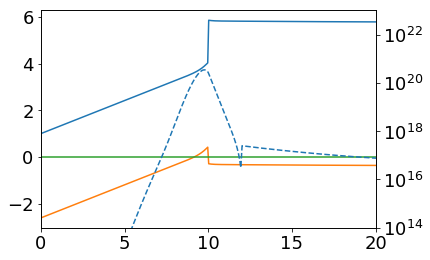

In [25]:
plt.figure()
plt.plot(m.zp,m.Ec)
plt.plot(m.zp,m.Ev)
plt.plot(m.zp,m.EF)

plt.twinx()
plt.plot(m.zp,m.p/(1/cm**3),'--')
plt.plot(m.zp,m.n/(1/cm**3),'--')
plt.yscale('log')
plt.ylim(1e14,1e23)
plt.xlim(0,20)

In [44]:
import numpy as np

In [75]:
sw=scm.hpsi.T[:,:,:]/np.max(np.abs(scm.hpsi.T[:,:,:]),axis=0) *.05 + scm.hen.T[:,:,:]

(5, 11.9)

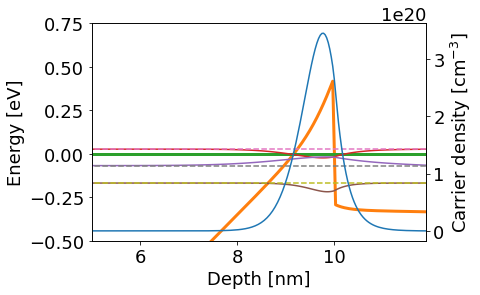

In [76]:
plt.figure()
plt.plot(m.zp,m.Ec,linewidth=3)
plt.plot(m.zp,m.Ev,linewidth=3)
plt.plot(m.zp,m.EF,linewidth=3)
plt.plot(scm.zp,sw[:,:1,0])
plt.plot(scm.zp,sw[:,:1,1])
plt.plot(scm.zp,sw[:,:1,2])
plt.plot(scm.zp,scm.hen.T[:,0,:],'--')
plt.ylim(-.5,.75)
plt.ylabel("Energy [eV]")
plt.xlabel("Depth [nm]")

plt.twinx()
plt.plot(m.zp,m.p/(1/cm**3),'-')
#plt.plot(m.zp,m.n/(1/cm**3),'--')
#plt.yscale('lin')
#plt.ylim(1e14,1e23)
plt.ylabel("Carrier density [cm$^{-3}$]")
plt.xlim(5,11.9)

In [8]:
m.p.integrate(definite=True)/(1/cm**2)  /1e13

Function(3.399070104877825)

In [9]:
mbkp=MultibandKP(scm)

Assembling k.p matrices ...
Done assembly.


In [10]:
kt,uens,normsqs,weights=mbkp.solve()
scl._cs[1].solve()
scl._fs[0].isolve()

0.13751956048299016

(0, 20)

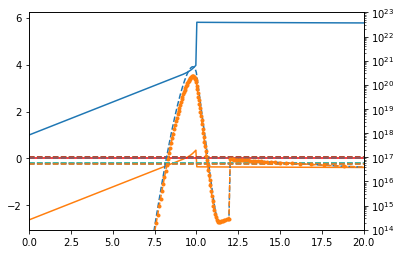

In [46]:
from pynitride.mesh import PointFunction
from pynitride.paramdb import k
plt.figure()
plt.plot(m.zp,m.Ec)
plt.plot(m.zp,m.Ev)
plt.plot(m.zp,m.EF,'r')
plt.plot(m.zp,PointFunction(m,value=uens[0][:10]).T,'--')

#plt.xlim(7.5,12.5)
#plt.ylim(-.3,.4)

plt.twinx()
plt.plot(m.zp,m.p/(1/cm**3),'--')
plt.plot(m.zp,m.pderiv*k*m.T.tpf()/(1/cm**3),'.--')
plt.plot(m.zp,m.n/(1/cm**3),'--')
plt.yscale('log')
plt.ylim(1e14,1e23)
plt.xlim(0,20)

In [18]:
m.p.integrate(definite=True)/(1/cm**2)  /1e13

Function(5.8598290582396855)

# KPSolver

In [3]:
m,[scm,clm]=gan_pfet(10*nm,200*nm,Ndef=5e16/cm**3,)

In [4]:
Equilibrium(m)

In [5]:
scl=SelfConsistentLoop(fieldsolvers=[PoissonSolver(m)],carriersolvers=[MultibandKP(scm),Semiclassical(scm,'electron'),Semiclassical(clm)])

Assembling k.p matrices ...
Done assembly.
Using explicit masses from file
Using explicit masses from file


In [6]:
%%timeit -n 1 -r 1
scl.ramp_epsfactor(start=1e1,max_iter=30)

Starting eps factor ramp from 10 to 1
  Eps factor: 1.00e+01
  Starting SC loop
    iter:   0  err: 3.81e-13  activ: 1
    Loop finished in  1 iterations with err=3.81377e-13
  Eps factor: 6.31e+00
  Starting SC loop
    iter:   0  err: 5.05e-01  activ: 1
    iter:   1  err: 7.55e-14  activ: 1
    Loop finished in  2 iterations with err=7.54671e-14
  Eps factor: 2.51e+00
  Starting SC loop
    iter:   0  err: 2.07e+00  activ: 1
    iter:   1  err: 5.47e-01  activ: 1
    iter:   2  err: 2.21e-01  activ: 1
    iter:   3  err: 7.03e-02  activ: 1
    iter:   4  err: 7.20e-02  activ: 1
    Retrying with Poisson activation=0.5
           iter:   4  err: 7.55e-02
    Retrying with Poisson activation=0.25
           iter:   4  err: 7.71e-02
    Retrying with Poisson activation=0.125
           iter:   4  err: 7.79e-02
    Retrying with Poisson activation=0.0625
  Failure: Couldn't reduce error in SC loop
  Restoring at 6.31e+00
  Eps factor: 3.98e+00
  Starting SC loop
    iter:   0  err: 4.69

(0, 20)

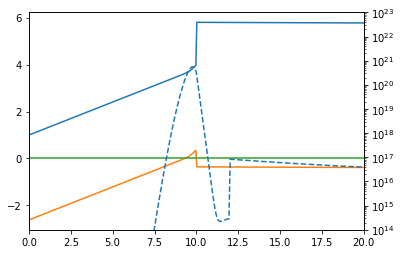

In [7]:
plt.figure()
plt.plot(m.zp,m.Ec)
plt.plot(m.zp,m.Ev)
plt.plot(m.zp,m.EF)

plt.twinx()
plt.plot(m.zp,m.p/(1/cm**3),'--')
#plt.plot(m.zp,m.pderiv*k*m.T.tpf()/(1/cm**3),'.--')
plt.plot(m.zp,m.n/(1/cm**3),'--')
plt.yscale('log')
plt.ylim(1e14,1e23)
plt.xlim(0,20)

In [ ]:
plt.figure()
plt.plot(m.zp,m.Ec)
plt.plot(m.zp,m.Ev)
plt.plot(m.zp,m.EF)

plt.plot

#plt.twinx()
#plt.plot(m.zp,m.p/(1/cm**3),'--')
#plt.plot(m.zp,m.n/(1/cm**3),'--')
#plt.yscale('log')
#plt.ylim(1e14,1e23)
#plt.xlim(0,20)

In [24]:
m.p.integrate(definite=True)/(1/cm**2)  /1e13

Function(3.414648592697289)

# Schro then KPSolver

In [20]:
from pynitride.visual import log
import numpy as np
log._depth=0
log._showlevel=np.inf

In [21]:
m,[scm,clm]=gan_pfet(10*nm,200*nm,Ndef=5e16/cm**3,)

In [22]:
Equilibrium(m)

In [11]:
scl=SelfConsistentLoop(fieldsolvers=[PoissonSolver(m)],carriersolvers=[Schrodinger(scm,'hole'),Semiclassical(scm,'electron'),Semiclassical(clm)])
scl.ramp_epsfactor(start=1e3,max_iter=20)
mbkp=MultibandKP(scm)
for cs in [mbkp,Schrodinger(scm,'electron'),Semiclassical(clm)]:
    cs.solve()
print(scl._fs[0].isolve())
for cs in [mbkp,Semiclassical(scm,'electron'),Semiclassical(clm)]:
    cs.solve()
print(scl._fs[0].isolve())
#scl=SelfConsistentLoop(fieldsolvers=[PoissonSolver(m)],carriersolvers=[MultibandKP(scm),Semiclassical(scm,'electron'),Semiclassical(clm)])
#scl.loop()

Using explicit masses from file
Using explicit masses from file
Starting eps factor ramp from 1000 to 1
  Eps factor: 1.00e+03
  Poisson iSolve
  Starting SC loop
    Using averaged effective mass to parabolically populate schrodinger bands
    Poisson iSolve
    Expanding function p
    Expanding function pderiv
    Expanding function n
    Expanding function nderiv
    iter:   0  err: 4.53e-16  activ: 1
    Loop finished in  1 iterations with err=4.52909e-16
  Eps factor: 6.31e+02
  Poisson iSolve
  Starting SC loop
    Using averaged effective mass to parabolically populate schrodinger bands
    Poisson iSolve
    iter:   0  err: 5.05e-03  activ: 1
    Using averaged effective mass to parabolically populate schrodinger bands
    Poisson iSolve
    iter:   1  err: 7.23e-16  activ: 1
    Loop finished in  2 iterations with err=7.22686e-16
  Eps factor: 2.51e+02
  Poisson iSolve
  Starting SC loop
    Using averaged effective mass to parabolically populate schrodinger bands
    Poisson

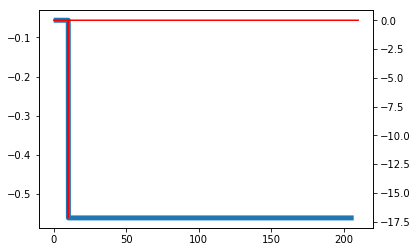

In [31]:
plt.figure()
plt.plot(m.zm,m.P,linewidth=5)
plt.twinx()
plt.plot(m.zp,m.DP,'r')

In [23]:
%%timeit -n 1 -r 1
scl=SelfConsistentLoop(fieldsolvers=[PoissonSolver(m)],carriersolvers=[Schrodinger(scm,'hole'),Semiclassical(scm,'electron'),Semiclassical(clm)])
scl.ramp_epsfactor(start=1e3,max_iter=20)
#mbkp=MultibandKP(scm)
#for cs in [mbkp,Schrodinger(scm,'electron'),Semiclassical(clm)]:
#    cs.solve()
#print(scl._fs[0].isolve())
#for cs in [mbkp,Schrodinger(scm,'electron'),Semiclassical(clm)]:
#    cs.solve()
#print(scl._fs[0].isolve())
psm=PoissonSolver(m)
psm.solve()
scl=SelfConsistentLoop(fieldsolvers=[psm],carriersolvers=[MultibandKP(scm),Semiclassical(scm,'electron'),Semiclassical(clm)])
scl.loop(tol=1e-8)

Using explicit masses from file
Using explicit masses from file
Starting eps factor ramp from 1000 to 1
  Eps factor: 1.00e+03
  Poisson iSolve
  Starting SC loop
    Using averaged effective mass to parabolically populate schrodinger bands
    Poisson iSolve
    Expanding function p
    Expanding function pderiv
    Expanding function n
    Expanding function nderiv
    iter:   0  err: 4.53e-16  activ: 1
    Loop finished in  1 iterations with err=4.52909e-16
  Eps factor: 6.31e+02
  Poisson iSolve
  Starting SC loop
    Using averaged effective mass to parabolically populate schrodinger bands
    Poisson iSolve
    iter:   0  err: 5.05e-03  activ: 1
    Using averaged effective mass to parabolically populate schrodinger bands
    Poisson iSolve
    iter:   1  err: 7.23e-16  activ: 1
    Loop finished in  2 iterations with err=7.22686e-16
  Eps factor: 2.51e+02
  Poisson iSolve
  Starting SC loop
    Using averaged effective mass to parabolically populate schrodinger bands
    Poisson

In [28]:
%%timeit -n 1 -r 1
scl.ramp_epsfactor(start=1e1,max_iter=30)

            Starting eps factor ramp from 10 to 1
              Eps factor: 1.00e+01
              Starting SC loop
                iter:   0  err: 3.81e-13  activ: 1
                Loop finished in  1 iterations with err=3.81377e-13
              Eps factor: 6.31e+00
              Starting SC loop
                iter:   0  err: 5.05e-01  activ: 1
                iter:   1  err: 7.55e-14  activ: 1
                Loop finished in  2 iterations with err=7.54671e-14
              Eps factor: 3.55e+00
              Starting SC loop
                iter:   0  err: 1.07e+00  activ: 1
                iter:   1  err: 3.44e-07  activ: 1
                Loop finished in  2 iterations with err=3.43514e-07
              Eps factor: 2.00e+00
              Starting SC loop
                iter:   0  err: 1.89e+00  activ: 1
                iter:   1  err: 9.20e+00  activ: 1
                Retrying with Poisson activation=0.5
                       iter:   1  err: 3.51e+00
                Retrying

(0, 20)

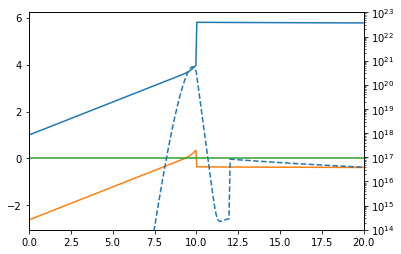

In [19]:
plt.figure()
plt.plot(m.zp,m.Ec)
plt.plot(m.zp,m.Ev)
plt.plot(m.zp,m.EF)

plt.twinx()
plt.plot(m.zp,m.p/(1/cm**3),'--')
#plt.plot(m.zp,m.pderiv*k*m.T.tpf()/(1/cm**3),'.--')
plt.plot(m.zp,m.n/(1/cm**3),'--')
plt.yscale('log')
plt.ylim(1e14,1e23)
plt.xlim(0,20)

In [ ]:
plt.figure()
plt.plot(m.zp,m.Ec)
plt.plot(m.zp,m.Ev)
plt.plot(m.zp,m.EF)

plt.plot

#plt.twinx()
#plt.plot(m.zp,m.p/(1/cm**3),'--')
#plt.plot(m.zp,m.n/(1/cm**3),'--')
#plt.yscale('log')
#plt.ylim(1e14,1e23)
#plt.xlim(0,20)

In [24]:
m.p.integrate(definite=True)/(1/cm**2)  /1e13

Function(3.414648592697289)